# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** [To be provided]

**Date:** [To be provided]

In [ ]:
# Problem 1: Solved on paper, pdf added to github repo.



In [1]:
#Problem 2:


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Load the dataset
file_path = '/content/ForeignGifts_edu.csv'
df = pd.read_csv(file_path)
display(df.head())

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


,Foreign Gift Amount
count,2.822100e+04
mean,5.882327e+05
std,3.222011e+06
min,-5.377700e+05
25%,5.700000e+03
50%,9.461500e+04
75%,3.761420e+05
max,1.000000e+08


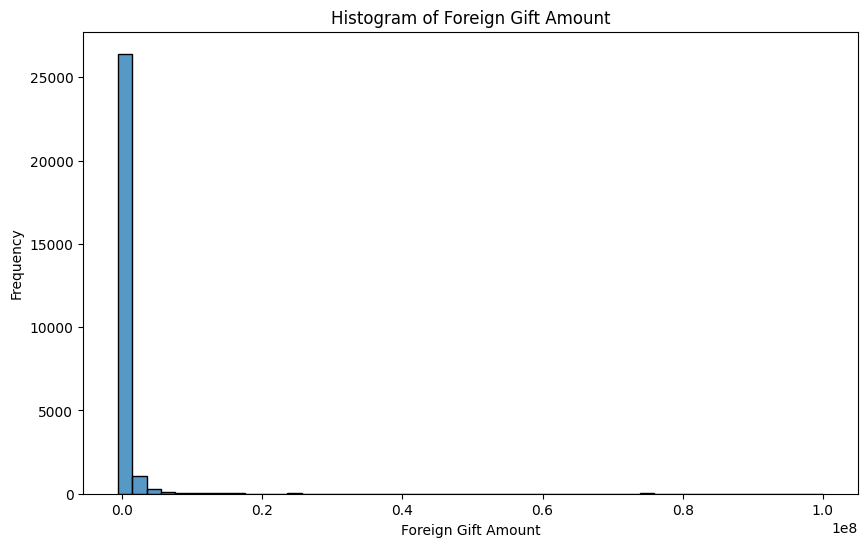

In [2]:
# 2. For Foreign Gift Amount, create a histogram and describe the variable.
display(df['Foreign Gift Amount'].describe())

plt.figure(figsize=(10, 6))
sns.histplot(df['Foreign Gift Amount'].dropna(), bins=50, kde=False)
plt.title('Histogram of Foreign Gift Amount')
plt.xlabel('Foreign Gift Amount')
plt.ylabel('Frequency')
plt.show()

**Findings:** The `Foreign Gift Amount` variable is heavily right-skewed. The vast majority of gifts are relatively small compared to a few extremely large outliers, which compresses the histogram and makes it difficult to see the distribution of typical gift amounts without a log transformation.

,Count,Proportion (%)
Gift Type,,
Contract,17274,61.209737
Monetary Gift,10936,38.751285
Real Estate,11,0.038978


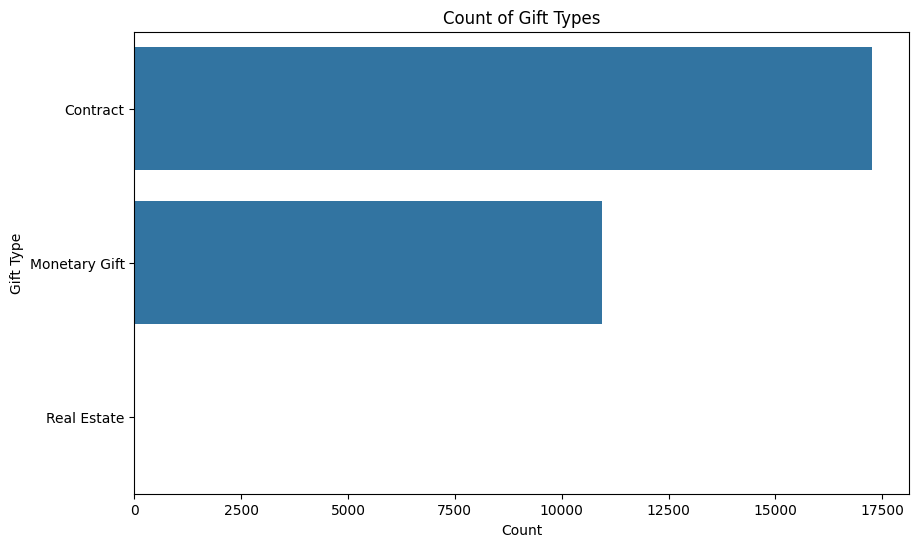

In [3]:
# 3. For Gift Type, create a histogram or value counts table.
# What proportion of the gifts are contracts, real estate, and monetary gifts?

gift_type_counts = df['Gift Type'].value_counts()
gift_type_props = df['Gift Type'].value_counts(normalize=True) * 100

display(pd.DataFrame({'Count': gift_type_counts, 'Proportion (%)': gift_type_props}))

plt.figure(figsize=(10, 6))
sns.countplot(y='Gift Type', data=df, order=df['Gift Type'].value_counts().index)
plt.title('Count of Gift Types')
plt.xlabel('Count')
plt.ylabel('Gift Type')
plt.show()

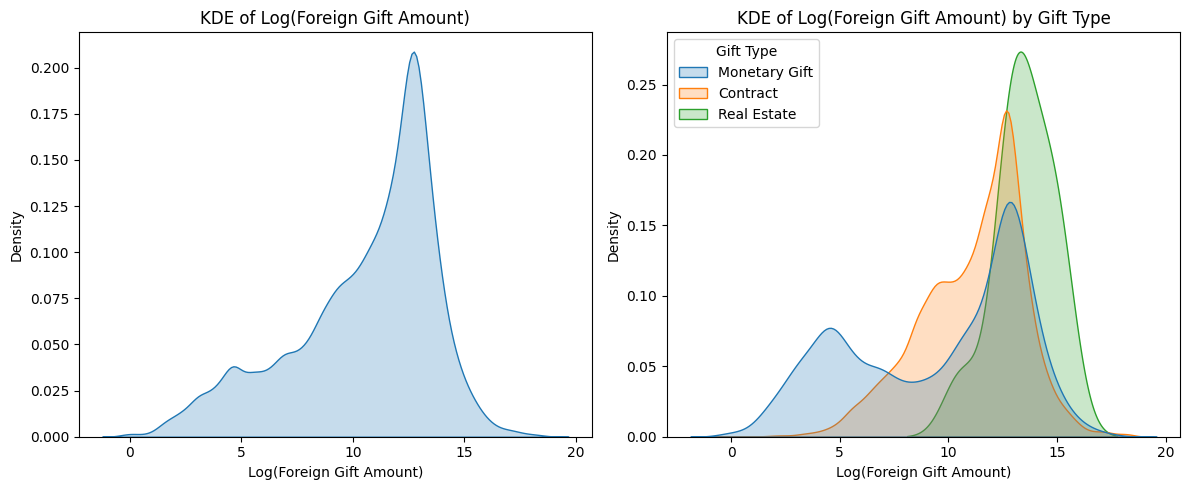

In [4]:
# 4. Create a kernel density plot of the log of Foreign Gift Amount,
# and then a kernel density plot of the log conditional on gift type.

# Calculate log of Foreign Gift Amount (ignoring zeros and negative values if any)
df['Log_Gift_Amount'] = np.log(df[df['Foreign Gift Amount'] > 0]['Foreign Gift Amount'])

plt.figure(figsize=(12, 5))

# Overall KDE
plt.subplot(1, 2, 1)
sns.kdeplot(data=df, x='Log_Gift_Amount', fill=True)
plt.title('KDE of Log(Foreign Gift Amount)')
plt.xlabel('Log(Foreign Gift Amount)')

# Conditional KDE by Gift Type
plt.subplot(1, 2, 2)
sns.kdeplot(data=df, x='Log_Gift_Amount', hue='Gift Type', common_norm=False, fill=True)
plt.title('KDE of Log(Foreign Gift Amount) by Gift Type')
plt.xlabel('Log(Foreign Gift Amount)')

plt.tight_layout()
plt.show()

In [8]:
# 5. What are the top 15 countries in terms of the number of gifts?
# What are the top 15 countries in terms of the amount given?

top_countries_by_number = df['Country of Giftor'].value_counts().head(15)
print("Top 15 Countries by Number of Gifts:")
display(pd.DataFrame(top_countries_by_number))

print("\nTop 15 Countries by Amount Given:")
top_countries_by_amount = df.groupby('Country of Giftor')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15)
display(pd.DataFrame(top_countries_by_amount))

Top 15 Countries by Number of Gifts:


,count
Country of Giftor,
ENGLAND,3655
CHINA,2461
CANADA,2344
JAPAN,1896
SWITZERLAND,1676
SAUDI ARABIA,1610
FRANCE,1437
GERMANY,1394
HONG KONG,1080



Top 15 Countries by Amount Given:


,Foreign Gift Amount
Country of Giftor,
QATAR,2706240869
ENGLAND,1464906771
CHINA,1237952112
SAUDI ARABIA,1065205930
BERMUDA,899593972
CANADA,898160656
HONG KONG,887402529
JAPAN,655954776
SWITZERLAND,619899445


In [9]:
# 6. Which giftors provide the most money, in total?

top_giftors = df.groupby('Giftor Name')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(10)
print("Top 10 Giftors by Total Amount:")
display(pd.DataFrame(top_giftors))

Top 10 Giftors by Total Amount:


,Foreign Gift Amount
Giftor Name,
Qatar Foundation,1166503744
Qatar Foundation/Qatar National Res,796197000
Qatar Foundation for Education,373945215
Anonymous,338793629
Saudi Arabian Cultural Mission,275221475
HCL,190000000
Church of Jesus Christ of LDS,185203715
Emirates Institute for Advanced Sc,170641244
QIC,148355497


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]